In [1]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
from qsmp import tree
from spectrum import MultiTapering
from scipy.io import loadmat

In [2]:
plt.rcParams.update({
    "text.usetex": True,    
    "font.size": 12
})
img_dir = Path('../results/img')

In [3]:
data_file = Path('../data/morlet/morlet_signal.npz')
with np.load(data_file, allow_pickle=True) as data:
    T = data['T']
    fs = data['fs']
    wave_len = data['wave_len']
    freq = data['freq']
    SNRdB = data['SNRdB']

In [19]:
def find_tau(k, subseq_len, density, NNindex, NNdist):    
    max_tau = np.max(NNdist)
    min_tau = np.min(NNdist[NNdist>0])    
    step = (max_tau - min_tau)/2
    tau = min_tau + step
    prev_left = min_tau
    prev_right = max_tau
    while True:        
        NNd, NNi, modes, cluster_size = tree.tree2clusters(
            subseq_len, density, NNindex, NNdist, tau)
        n_modes = modes.size        
        if n_modes == k:
            break
        elif n_modes > k:
            step = (prev_right - tau)/2
            prev_left = tau
            tau = tau + step            
        else:
            step = (tau - prev_left)/2
            prev_right = tau
            tau = tau - step
    return tau

In [4]:
qsmp_file = Path('../results/morlet/qsmp_m-512_sigma-0.9_1.0_1.1_1.2_2.0_rect-50_minfilt-256.npz')
with np.load(qsmp_file) as data:
    density = data['density'].T
    NNdist = data['profile'].T
    NNindex = data['indices'].T

i_sigma = 1
max_modes, n_neighbors = 6, 0
subseq_len = 512

In [20]:
k = 6
tau = find_tau(k, subseq_len, density[i_sigma], NNindex[i_sigma], NNdist[i_sigma])
print(tau)

20.479319257447415


In [25]:
tau = 20.5
NNd, NNi, modes, cluster_size = tree.tree2clusters(
    subseq_len, density[i_sigma], NNindex[i_sigma],
    NNdist[i_sigma], tau
)

sample, idx = tree.get_neighbors(
    T, subseq_len, density[i_sigma], NNi,
    NNd, modes, max_modes, n_neighbors
)

modes = np.vstack([m[0] for m in sample])

In [26]:
snippets_file = Path('../results/morlet/snippets_sub-512_per-50.mat')
with snippets_file.open('rb') as f:
    mat_vars = loadmat(f)
snippets = mat_vars['snippets']
snippet_idx = mat_vars['snippetidx'].flatten()
snippet_frac = mat_vars['fraction'].flatten()
isort = np.argsort(-snippet_frac)
snippets = snippets[isort]
snippet_idx = snippet_idx[isort]
snippet_frac = snippet_frac[isort]

In [27]:
sikmeans_file = Path('../results/morlet/sikmeans_k-6_P-512_wlen-768.npz')
with np.load(sikmeans_file) as data:
    centroids = data['centroids']
    labels = data['labels']
    shifts = data['shifts']
    distances = data['distances']

ul, label_count = np.unique(labels, return_counts=True)
isort = np.argsort(-label_count)
centroids = centroids[isort]
label_count = label_count[isort]
label_coverage = label_count / label_count.sum()
label_coverage

array([0.66816817, 0.18618619, 0.10960961, 0.01951952, 0.01201201,
       0.0045045 ])

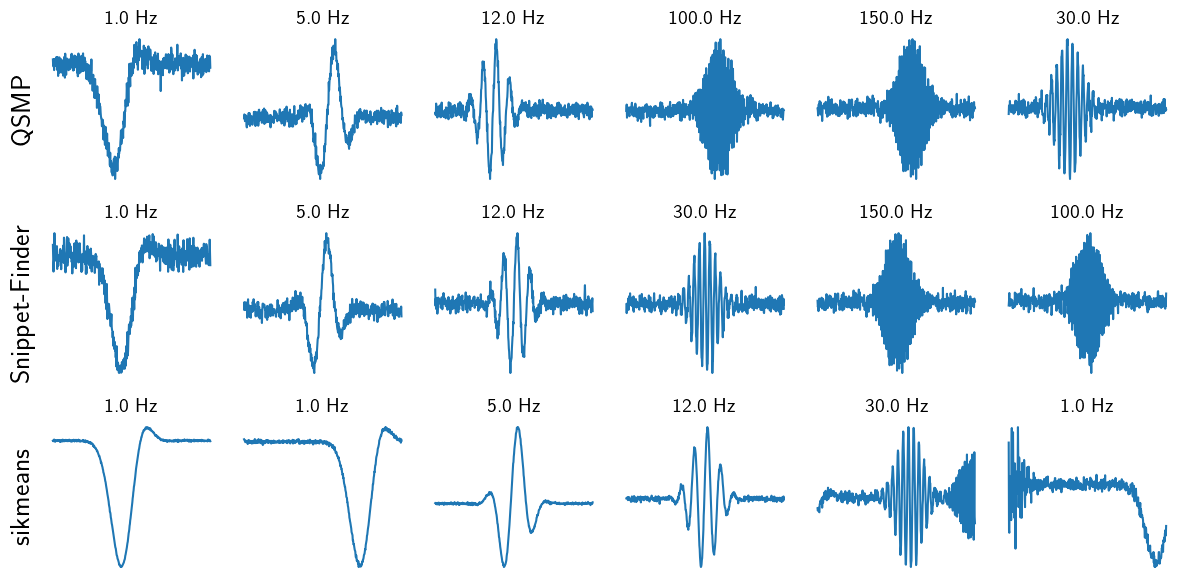

In [28]:
rows = (modes, snippets, centroids)
ylabels = ['QSMP', 'Snippet-Finder', 'sikmeans']
n_rows = len(rows)

fig, ax = plt.subplots(n_rows, max_modes, figsize=(2*max_modes, 2*n_rows))
for i, row in enumerate(rows):
    for j, mode  in enumerate(row):        
        ax[i,j].plot(mode)
        mts = MultiTapering(mode, NW=3, sampling=fs)
        PSD, f = mts.psd, mts.frequencies()
        f_max = f[np.argmax(PSD)]
        f_max = 1.0 if f_max == 0 else f_max
        ax[i,j].set_title(f'{f_max} Hz')
        ax[i,j].set_frame_on(False)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        if j == 0:
            ax[i,j].set_ylabel(ylabels[i], fontsize=20)

plt.tight_layout()            
fpath = img_dir.joinpath('QSMP_vs_Snippet-Finder_vs_sikmeans_morlet.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

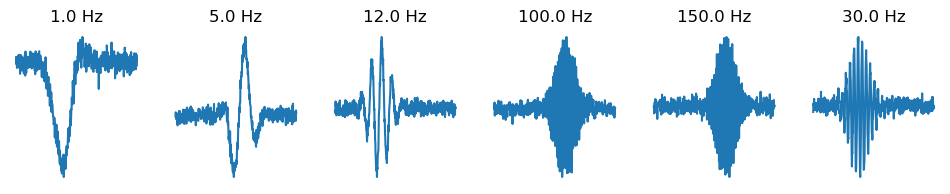

In [28]:
fig, ax = plt.subplots(1, max_modes, figsize=(2*max_modes, 2))
for i in range(max_modes):
    mode = sample[i][0]
    ax[i].plot(mode)
    mts = MultiTapering(mode, NW=3, sampling=fs)
    PSD, f = mts.psd, mts.frequencies()
    f_max = f[np.argmax(PSD)]
    f_max = 1.0 if f_max == 0 else f_max #MTM is unable to estimate peak at 1 Hz
    ax[i].set_title(f'{f_max} Hz')
    ax[i].axis('off')

In [63]:
uf, cf = np.unique(freq, return_counts=True)
isort = np.argsort(-cf)
uf[isort]

array([  1,   5,  12,  30, 150, 100])

In [93]:
modes.size

3072

In [18]:
round(512*0.30)

154

In [84]:
idx[0][0]

386073

In [98]:
np.array(QSMP_coverage)/np.array(QSMP_coverage).sum()

array([9.93786267e-01, 6.20190007e-03, 1.08220675e-05, 3.69825654e-07,
       3.20651482e-07, 3.20388860e-07])

In [99]:
modes.size

3072

In [105]:
np.array(QSMP_coverage) * 512e6

array([1.75324400e+02, 1.09414312e+00, 1.90923598e-03, 6.52448754e-05,
       5.65695368e-05, 5.65232049e-05])